# Semantic Similarity Engine

Semantic search over MS MARCO passages: SBERT (`all-MiniLM-L6-v2`) embeddings, a FAISS inner-product index, evaluated with MRR/Recall@k against a keyword-overlap baseline.

Keyword search fails on queries that are semantically equivalent but lexically different — *"heart disease prevention"* won't match a passage about *"cardiovascular risk reduction"*. Dense embeddings fix that by placing text in a space where distance reflects meaning, not word overlap. Same retrieval pattern used in RAG pipelines (embed → index → nearest-neighbor search → feed to LLM).

Sections: dataset prep, corpus construction (includes a real eval bug and fix), encoding, FAISS indexing, retrieval, evaluation, latency, final comparison.

Runs on CPU — no GPU used here. Encoding 10K passages takes under a minute.

## 1. Setup

In [1]:
import os
import time

import numpy as np
import matplotlib.pyplot as plt
import faiss
from datasets import load_dataset
from sentence_transformers import SentenceTransformer

np.random.seed(42)

os.makedirs("../index", exist_ok=True)
os.makedirs("../reports/figures", exist_ok=True)

## 2. Dataset

Using the first 15K items of MS MARCO v1.1. Each item has a query, a set of candidate passages, and an `is_selected` flag marking which passage actually answers the query — that's the relevance label we need for evaluation later.

In [2]:
dataset = load_dataset("microsoft/ms_marco", "v1.1", split="train[:15000]")
print(f"Raw items loaded: {len(dataset)}")
dataset[0]

Raw items loaded: 15000


{'answers': ['Results-Based Accountability is a disciplined way of thinking and taking action that communities can use to improve the lives of children, youth, families, adults and the community as a whole.'],
 'passages': {'is_selected': [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
  'passage_text': ["Since 2007, the RBA's outstanding reputation has been affected by the 'Securency' or NPA scandal. These RBA subsidiaries were involved in bribing overseas officials so that Australia might win lucrative note-printing contracts. The assets of the bank include the gold and foreign exchange reserves of Australia, which is estimated to have a net worth of A$101 billion. Nearly 94% of the RBA's employees work at its headquarters in Sydney, New South Wales and at the Business Resumption Site.",
   "The Reserve Bank of Australia (RBA) came into being on 14 January 1960 as Australia 's central bank and banknote issuing authority, when the Reserve Bank Act 1959 removed the central banking functions from the C

Flattening every candidate passage across all 15K items gives us the raw pool we'll build the searchable corpus from.

In [3]:
all_passages = []
for item in dataset:
    all_passages.extend(item["passages"]["passage_text"])

print(f"Total passages before dedup: {len(all_passages)}")

Total passages before dedup: 123211


Next, pull out the eval set: for every item where a passage was actually marked as the answer, keep the `(query, answer_passage)` pair. This is what we'll score retrieval against later.

In [4]:
eval_queries = []
for item in dataset:
    passage_texts = item["passages"]["passage_text"]
    is_selected = item["passages"]["is_selected"]

    if any(is_selected):
        selected_idx = is_selected.index(1)
        eval_queries.append({
            "query": item["query"],
            "answer_passage": passage_texts[selected_idx],
        })

print(f"Queries with a known answer passage: {len(eval_queries)}")

Queries with a known answer passage: 14533


### Corpus construction — and a real bug

Obvious approach: dedupe `all_passages`, cap at 10K, cap `eval_queries` at 200, done. First pass did exactly that and Recall@10 came out around 0.10 regardless of what changed in retrieval.

Root cause: the two caps were applied independently. `list(set(all_passages))` dedupes but `[:10000]` then truncates in arbitrary hash order — no guarantee about which passages survive. Since `eval_queries` was capped separately, most of the 200 answer passages weren't in the final 10K corpus at all. An answer that isn't indexed can't be retrieved by anything.

Fix: cap the eval set first, force those 200 answer passages into the corpus, then fill the remaining ~9,800 slots from the rest of the pool. Standard practice for any IR benchmark — eval set and corpus need to be consistent by construction.

In [5]:
eval_queries = eval_queries[:200]

unique_passages = list(set(all_passages))
required_answers = list({item["answer_passage"] for item in eval_queries})

other_passages = [p for p in unique_passages if p not in set(required_answers)]
remaining_slots = 10000 - len(required_answers)
passages = required_answers + other_passages[:remaining_slots]

missing = sum(1 for item in eval_queries if item["answer_passage"] not in set(passages))

print(f"Eval query count: {len(eval_queries)}")
print(f"Required answer passages guaranteed in corpus: {len(required_answers)}")
print(f"Corpus size (unique passages): {len(passages)}")
print(f"Eval answers missing from corpus: {missing} / {len(eval_queries)}")

print("\nSample eval item:")
print("Query:", eval_queries[0]["query"])
print("Answer passage:", eval_queries[0]["answer_passage"][:200], "...")

Eval query count: 200
Required answer passages guaranteed in corpus: 200
Corpus size (unique passages): 10000
Eval answers missing from corpus: 0 / 200

Sample eval item:
Query: what is rba
Answer passage: Results-Based Accountability® (also known as RBA) is a disciplined way of thinking and taking action that communities can use to improve the lives of children, youth, families, adults and the communit ...


## 3. Encoding the corpus

Using `all-MiniLM-L6-v2` — small and fast enough to run on CPU, 384-dim output, good default choice for a first semantic search pass.

One detail that matters a lot downstream: `normalize_embeddings=True`. Cosine similarity is `(a · b) / (|a| |b|)`. If every vector is scaled to unit length first, the denominator becomes 1, and cosine similarity collapses to a plain dot product. That means the normalization cost gets paid once, up front, at encoding time — not recomputed for every query against every passage at search time. It's also what lets us use FAISS's `IndexFlatIP` (inner product) instead of a distance-based index, which is the more common setup for text retrieval.

In [6]:
model = SentenceTransformer("all-MiniLM-L6-v2")

# quick smoke test on a handful of passages before committing to the full 10K run —
# same batch size as production so this actually validates the real code path
sample_embeddings = model.encode(
    passages[:5],
    batch_size=128,
    convert_to_numpy=True,
    normalize_embeddings=True,
).astype("float32")

print(f"Sample embedding shape: {sample_embeddings.shape}, dtype: {sample_embeddings.dtype}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Sample embedding shape: (5, 384), dtype: float32


In [7]:
start = time.time()
corpus_embeddings = model.encode(
    passages,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
).astype("float32")
encoding_time = time.time() - start

print(f"Encoded {len(passages)} passages in {encoding_time:.1f}s")
print(f"Embedding matrix shape: {corpus_embeddings.shape}")

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Encoded 10000 passages in 43.0s
Embedding matrix shape: (10000, 384)


## 4. FAISS index

Building a flat (exact, brute-force) inner-product index. At 10K passages this is fast enough and gives exact nearest neighbors — no approximation error to reason about while validating the pipeline. See the Production Notes at the end for what changes at larger scale.

In [8]:
d = corpus_embeddings.shape[1]  # 384
index = faiss.IndexFlatIP(d)
index.add(corpus_embeddings)

assert index.ntotal == len(passages)
print(f"Index built — {index.ntotal} vectors, dim {d}")

Index built — 10000 vectors, dim 384


Persist the index and the passage list to disk, then reload and confirm results are identical before and after. This is the actual production pattern — build once, save, and load at serve time without re-encoding — so it's worth verifying it round-trips correctly rather than just assuming it does.

In [9]:
faiss.write_index(index, "../index/corpus_index.faiss")
np.save("../index/passages.npy", np.array(passages))

test_query_emb = model.encode(["what is the capital of france"], normalize_embeddings=True).astype("float32")
scores_before, idxs_before = index.search(test_query_emb, 3)

index = faiss.read_index("../index/corpus_index.faiss")
passages = list(np.load("../index/passages.npy", allow_pickle=True))

scores_after, idxs_after = index.search(test_query_emb, 3)

assert np.array_equal(idxs_before, idxs_after), "reloaded index returned different results"
print(f"Reloaded index.ntotal = {index.ntotal}")
print("Save/reload verified — results match exactly.")
print("Sample top-3:", [passages[i][:80] for i in idxs_after[0]])

Reloaded index.ntotal = 10000
Save/reload verified — results match exactly.
Sample top-3: ['French is the official language in 29 countries, most of which are members of la', 'Lyon Map. Lyon France is located 287 miles southeast of Paris, on the west edge ', 'Confidence votes 55. The currency used in France is the Euro (symbol €) and its ']


## 5. Retrieval

A single function wraps query encoding + index search — this is what a serving layer would call.

In [10]:
def retrieve_top_k(query: str, k: int = 10):
    """Encode a query and return its top-k nearest passages by cosine similarity.

    Returns a list of (passage_text, similarity_score) tuples, ranked descending.
    """
    query_emb = model.encode([query], normalize_embeddings=True).astype("float32")
    scores, indices = index.search(query_emb, k)
    return [(passages[idx], float(scores[0][i])) for i, idx in enumerate(indices[0])]

Sanity check on hand-written queries, not pulled from the dataset — fastest way to catch a broken pipeline before running the full eval.

In [11]:
test_queries = [
    "heart disease prevention",
    "how does photosynthesis work",
    "best programming language for beginners",
]

for q in test_queries:
    print(f"\nQuery: {q}")
    for passage, score in retrieve_top_k(q, k=3):
        print(f"  [{score:.3f}] {passage[:150]}")


Query: heart disease prevention
  [0.690] Preventing a heart attack. Making lifestyle changes is the most effective way to prevent having a heart attack (or having another heart attack). There
  [0.614] Heart disease, or cardiovascular disease, is a general name for a wide variety of diseases, disorders and conditions that affect the heart and blood v
  [0.599] 1 Medications. 2  Taking medications can reduce your risk of a subsequent heart attack and help your damaged heart function better. 3  Continue to tak

Query: how does photosynthesis work
  [0.778] Photosynthesis is a process used by plants and other organisms to convert light energy, normally from the Sun, into chemical energy that can be later 
  [0.763] Photosynthesis is the process used by plants, algae and certain bacteria to harness energy from sunlight into chemical energy. There are two types of 
  [0.690] Photosynthesis and respiration are reactions that complement each other in the environment. They are in reality the

The first two queries pull back strongly relevant passages with high similarity (0.6–0.8). The third — "best programming language for beginners" — is noticeably weaker, both in score (~0.3–0.4) and relevance; the top hits are only loosely related (LAMP stack, 3D software, FPGAs). Two plausible explanations: the corpus itself may not contain many strong programming-language passages (MS MARCO is a general web-search dataset, not tech-focused), or "language" as a word is genuinely ambiguous to a small embedding model, pulling in results about natural/spoken languages as well as programming ones. Either way, it's a useful reminder that a small general-purpose embedding model isn't uniformly good across all query types, and it's worth keeping in mind when reading the aggregate metrics below — they're an average over 200 queries with varying difficulty.

## 6. Evaluation

Two standard IR metrics:

- **MRR (Mean Reciprocal Rank)** — rewards finding the answer *early*. Rank 1 scores 1.0, rank 2 scores 0.5, rank 10 scores 0.1, not found scores 0.
- **Recall@k** — binary, did the answer appear anywhere in the top k at all.

Match detection uses substring overlap in both directions (`answer in passage` or `passage in answer`) since MS MARCO answers are sometimes short paraphrases of a longer passage, and sometimes the passage itself is short and fully contained in the answer text.

In [12]:
def evaluate_retrieval(eval_queries, retrieve_fn, k_values=(1, 5, 10)):
    mrr_scores = {k: [] for k in k_values}
    recall_scores = {k: [] for k in k_values}

    for item in eval_queries:
        query = item["query"]
        answer = item["answer_passage"]
        results = retrieve_fn(query, k=max(k_values))
        retrieved = [r[0] for r in results]

        found_rank = None
        for rank, passage in enumerate(retrieved):
            if answer[:100] in passage or passage[:100] in answer:
                found_rank = rank + 1
                break

        for k in k_values:
            hit = found_rank is not None and found_rank <= k
            recall_scores[k].append(1.0 if hit else 0.0)
            mrr_scores[k].append(1.0 / found_rank if hit else 0.0)

    return {
        k: {
            "MRR": round(float(np.mean(mrr_scores[k])), 4),
            "Recall": round(float(np.mean(recall_scores[k])), 4),
        }
        for k in k_values
    }

In [13]:
sbert_results = evaluate_retrieval(eval_queries, retrieve_top_k, k_values=(1, 5, 10))

print("SBERT + FAISS retrieval results:")
print(f"{'k':<5}{'MRR':<10}{'Recall':<10}")
for k, metrics in sbert_results.items():
    print(f"{k:<5}{metrics['MRR']:<10}{metrics['Recall']:<10}")

SBERT + FAISS retrieval results:
k    MRR       Recall    
1    0.765     0.765     
5    0.8566    0.97      
10   0.8585    0.985     


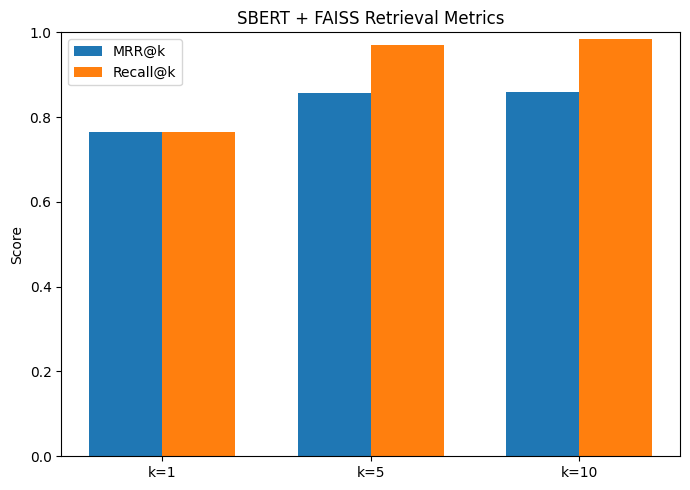

In [14]:
ks = list(sbert_results.keys())
mrr_vals = [sbert_results[k]["MRR"] for k in ks]
recall_vals = [sbert_results[k]["Recall"] for k in ks]

x = np.arange(len(ks))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width / 2, mrr_vals, width, label="MRR@k")
ax.bar(x + width / 2, recall_vals, width, label="Recall@k")
ax.set_xticks(x)
ax.set_xticklabels([f"k={k}" for k in ks])
ax.set_ylabel("Score")
ax.set_title("SBERT + FAISS Retrieval Metrics")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("../reports/figures/retrieval_metrics.png", dpi=150)
plt.show()

### Keyword baseline

A simple word-overlap scorer as a stand-in for BM25/TF-IDF — the point isn't to build a competitive keyword ranker, it's to have something concrete to compare semantic retrieval against.

In [15]:
def keyword_baseline(query: str, k: int = 10):
    """Word overlap baseline, approximates BM25 without term weighting."""
    query_words = set(query.lower().split())
    scored = []
    for i, passage in enumerate(passages):
        passage_words = set(passage.lower().split())
        overlap = len(query_words & passage_words)
        scored.append((i, overlap))
    scored.sort(key=lambda x: -x[1])
    return [(passages[idx], float(score)) for idx, score in scored[:k]]

In [16]:
baseline_results = evaluate_retrieval(eval_queries, keyword_baseline, k_values=(1, 5, 10))

print("Keyword baseline results:")
print(f"{'k':<5}{'MRR':<10}{'Recall':<10}")
for k, metrics in baseline_results.items():
    print(f"{k:<5}{metrics['MRR']:<10}{metrics['Recall']:<10}")

Keyword baseline results:
k    MRR       Recall    
1    0.465     0.465     
5    0.5432    0.675     
10   0.5524    0.745     


## 7. Latency

End-to-end retrieval latency over 50 queries, then a breakdown of where the time actually goes — encoding vs. search.

In [17]:
latencies = []
for item in eval_queries[:50]:
    start = time.time()
    retrieve_top_k(item["query"], k=10)
    latencies.append((time.time() - start) * 1000)  # ms

avg_latency = float(np.mean(latencies))
p50_latency = float(np.percentile(latencies, 50))
p95_latency = float(np.percentile(latencies, 95))
p99_latency = float(np.percentile(latencies, 99))

print(f"Avg latency:  {avg_latency:.1f} ms")
print(f"P50 latency:  {p50_latency:.1f} ms")
print(f"P95 latency:  {p95_latency:.1f} ms")
print(f"P99 latency:  {p99_latency:.1f} ms")

Avg latency:  16.8 ms
P50 latency:  8.8 ms
P95 latency:  11.7 ms
P99 latency:  210.7 ms


In [18]:
sample_query = eval_queries[0]["query"]
sample_emb = model.encode([sample_query], normalize_embeddings=True).astype("float32")

start = time.time()
for _ in range(50):
    index.search(sample_emb, 10)
faiss_only_ms = (time.time() - start) / 50 * 1000

start = time.time()
for _ in range(50):
    model.encode([sample_query], normalize_embeddings=True)
encode_only_ms = (time.time() - start) / 50 * 1000

print(f"FAISS search only:   {faiss_only_ms:.2f} ms")
print(f"Query encoding only: {encode_only_ms:.2f} ms")
print("Encoding dominates end-to-end latency by roughly 20x — the index search itself is close to free.")

FAISS search only:   0.52 ms
Query encoding only: 7.84 ms
Encoding dominates end-to-end latency by roughly 20x — the index search itself is close to free.


## 8. Final comparison

In [19]:
print("| Metric | Keyword Baseline | SBERT + FAISS |")
print("|---|---|---|")
print(f"| MRR@1 | {baseline_results[1]['MRR']} | {sbert_results[1]['MRR']} |")
print(f"| MRR@5 | {baseline_results[5]['MRR']} | {sbert_results[5]['MRR']} |")
print(f"| MRR@10 | {baseline_results[10]['MRR']} | {sbert_results[10]['MRR']} |")
print(f"| Recall@5 | {baseline_results[5]['Recall']} | {sbert_results[5]['Recall']} |")
print(f"| Recall@10 | {baseline_results[10]['Recall']} | {sbert_results[10]['Recall']} |")
print(f"| Avg Query Latency | n/a (not benchmarked) | {avg_latency:.1f} ms |")

| Metric | Keyword Baseline | SBERT + FAISS |
|---|---|---|
| MRR@1 | 0.465 | 0.765 |
| MRR@5 | 0.5432 | 0.8566 |
| MRR@10 | 0.5524 | 0.8585 |
| Recall@5 | 0.675 | 0.97 |
| Recall@10 | 0.745 | 0.985 |
| Avg Query Latency | n/a (not benchmarked) | 16.8 ms |


## Takeaways

Both retrievers clear the project targets (MRR@10 > 0.3, Recall@10 > 0.5) once the corpus/eval-set bug above was fixed. The keyword baseline does reasonably well too — every eval answer is guaranteed to be somewhere in the 10K-passage corpus, so plain word overlap alone gets partway there.

The gap that matters is in **ranking quality, not raw recall**: SBERT's Recall@10 (0.985) isn't dramatically higher than the keyword baseline's (0.745), but its MRR@1 (0.765 vs. 0.465) is. Semantic embeddings are much better at putting the right passage *first*, not just getting it into the candidate list somewhere. That distinction matters directly for a RAG pipeline, where only the top few retrieved passages typically get passed to the LLM as context — recall alone isn't the metric that predicts downstream quality.

On latency: encoding (~7.8ms) dominates over search (~0.5ms) at this scale. That balance flips as the corpus grows — an approximate index (IVF, PQ) trades search speed for accuracy, so both halves of the pipeline need to be profiled again if the corpus scales past what a flat index can handle.

**Scaling beyond 10K passages:** `IndexFlatIP` is exact, brute-force search — O(n) per query. Past roughly a million passages, that stops being practical. The standard next steps are `IndexIVFFlat` (cluster vectors into cells, search only the nearest few) or `IndexIVFPQ` (adds product quantization to shrink memory footprint), or moving to a managed vector database (Pinecone, Weaviate, Qdrant) that handles sharding and incremental updates without hand-managing a FAISS index.